In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rc('font', size = 14)
plt.rc('axes', labelsize =14 , titlesize = 14)
plt.rc('legend', fontsize = 14)
plt.rc('xtick' , labelsize =10)
plt.rc('ytick', labelsize =10)

In [3]:
np.random.seed(42)

m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.rand(m, 1)

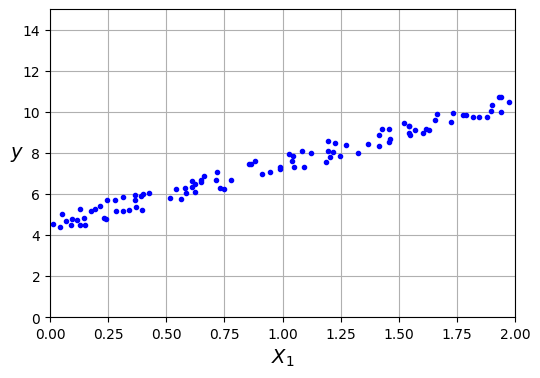

In [4]:
plt.figure(figsize= (6,4))
plt.plot(X, y, 'b.')
plt.xlabel('$X_1$')
plt.ylabel('$y$', rotation = 0)
plt.axis([0,2, 0, 15])
plt.grid();

In [5]:
matrix_a = np.array([[1, 2],
                     [3, 4]])

matrix_b = np.array([[5, 6],
                     [7, 8]])

result = matrix_a @ matrix_b
result = np.dot(matrix_a, matrix_b)

print('Matirx A: ')
print(matrix_a)
print('\nMatirx B: ')
print(matrix_b)
print('\nResult of Matrix multiplication (A @ B): ')
print(result)

Matirx A: 
[[1 2]
 [3 4]]

Matirx B: 
[[5 6]
 [7 8]]

Result of Matrix multiplication (A @ B): 
[[19 22]
 [43 50]]


In [6]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [7]:
import numpy as np

In [8]:
# X = np.array([
#     [1, 1, -1],
#     [2, 1, 3],
#     [4, -1, 2]
# ])

# y = np.array([5, 2, -1])

In [9]:
# np.linalg.inv(X.T @ X) @ X.T @ y

In [10]:
theta_best

array([[4.51359766],
       [2.98323418]])

In [12]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
X_new_b

array([[1., 0.],
       [1., 2.]])

In [13]:
X_new = np.array([[0], [2]])
X_new_b =  add_dummy_feature(X_new)

y_predict = X_new_b @ theta_best
y_predict

array([[ 4.51359766],
       [10.48006601]])

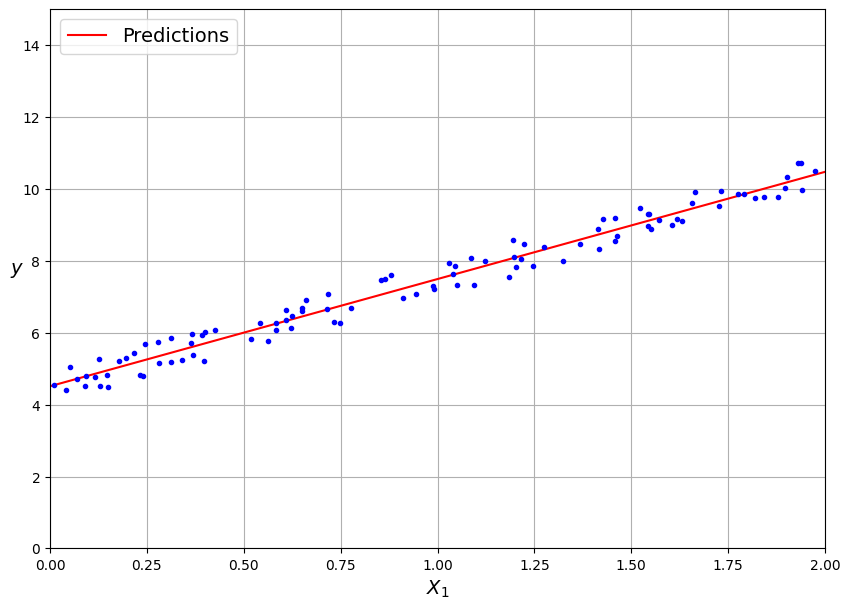

In [14]:
plt.figure(figsize=(10, 7))
plt.plot(X_new , y_predict, 'r-', label = 'Predictions')
plt.plot(X, y, 'b.')

plt.xlabel('$X_1$')
plt.ylabel('$y$' , rotation = 0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc = 'upper left')

plt.show()

In [15]:
def linreg(X, y):
  return np.linalg.inv(X.T @ X) @ X.T @ y

print(linreg(X_b , y))

[[4.51359766]
 [2.98323418]]


In [16]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.51359766]), array([[2.98323418]]))

In [17]:
eta = 0.1
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta = np.random.rand(2,1)

for epoch in range(n_epochs):
  gradient = 1 / m * 2 * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradient

In [18]:
theta

array([[4.51359766],
       [2.98323418]])

In [19]:
np.random.seed(42)
eta = 0.1
m = len(X_b)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
  for iteration in range(m):
    random_index = np.random.randint(m)
    xi = X_b[random_index : random_index + 1]
    yi = y[random_index : random_index +1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    theta = theta - eta * gradients

In [20]:
theta

array([[4.44771129],
       [2.89667006]])

In [21]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter = 1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)

sgd_reg.fit(X, y.ravel())

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [22]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.50316965]), array([2.99156535]))

In [23]:
from numpy.random import shuffle
from math import ceil

n_epochs = 50
eta = 0.1
m = len(X_b)
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
  shuffled_indices = np.random.permutation(m)
  X_b_shuffled = X_b[shuffled_indices]
  y_shuffled = y[shuffled_indices]
  for iteration in range(0, n_batches_per_epoch):
    idx = iteration * minibatch_size
    xi = X_b_shuffled[idx : idx + minibatch_size]
    yi = y_shuffled[idx : idx + minibatch_size]
    gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
    theta = theta - eta * gradients

In [24]:
theta

array([[4.52109876],
       [2.99157858]])

In [25]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

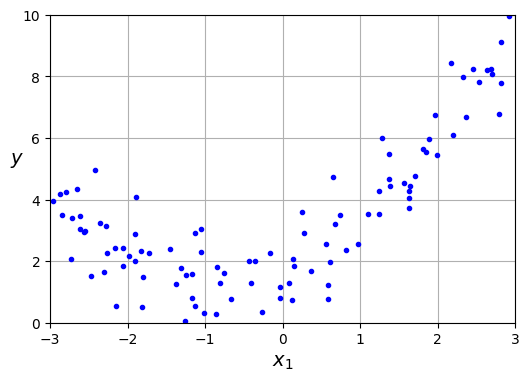

In [26]:
plt.figure(figsize= (6, 4))
plt.plot(X, y, 'b.')
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation = 0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

In [27]:
lin_reg.fit(X, y)

predictions = lin_reg.predict([[-3], [3]])
predictions

array([[1.03315352],
       [6.09487734]])

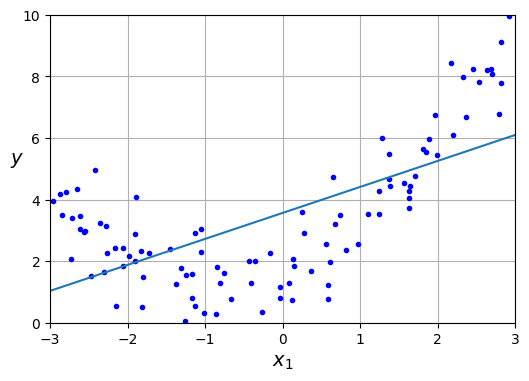

In [28]:
plt.figure(figsize = (6, 4))
plt.plot(X, y, 'b.')
plt.plot([-3,3],predictions)
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation = 0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

In [29]:
from sklearn.preprocessing import PolynomialFeatures

In [30]:
poly_features = PolynomialFeatures(degree=2, include_bias= False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [31]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [32]:
lin_reg.fit(X_poly , y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

In [33]:
model = lin_reg.fit(X_poly, y)
poly_predict = model.predict

In [34]:
X.shape

(100, 1)

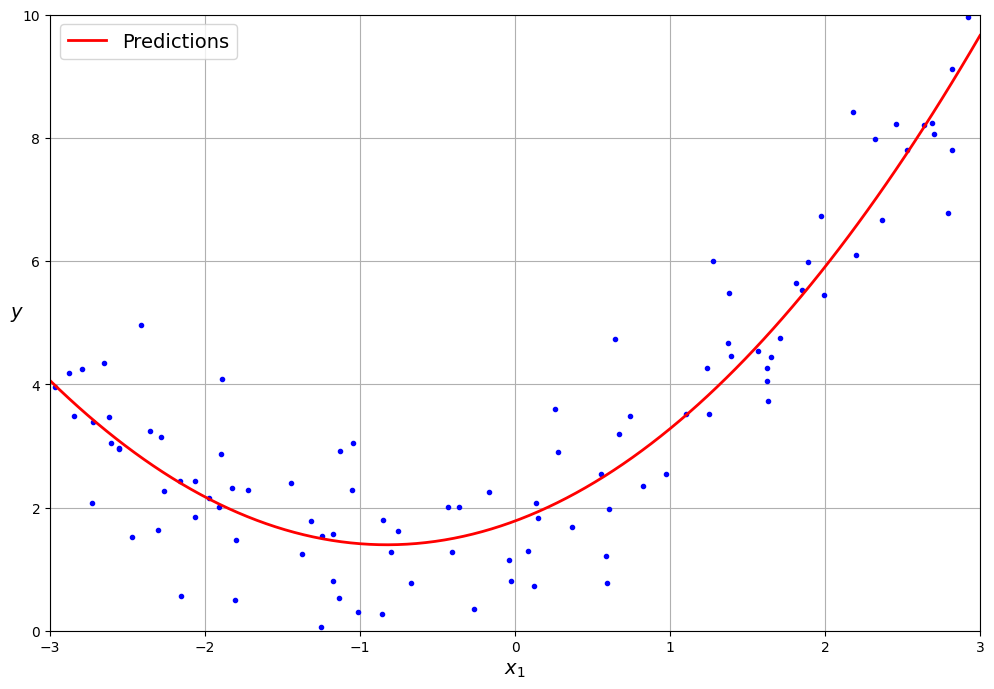

In [35]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize= (12, 8))
plt.plot(X, y, 'b.')
plt.plot(X_new, y_new, 'r-', linewidth = 2, label='Predictions')
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation = 0)
plt.legend(loc='upper left')
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

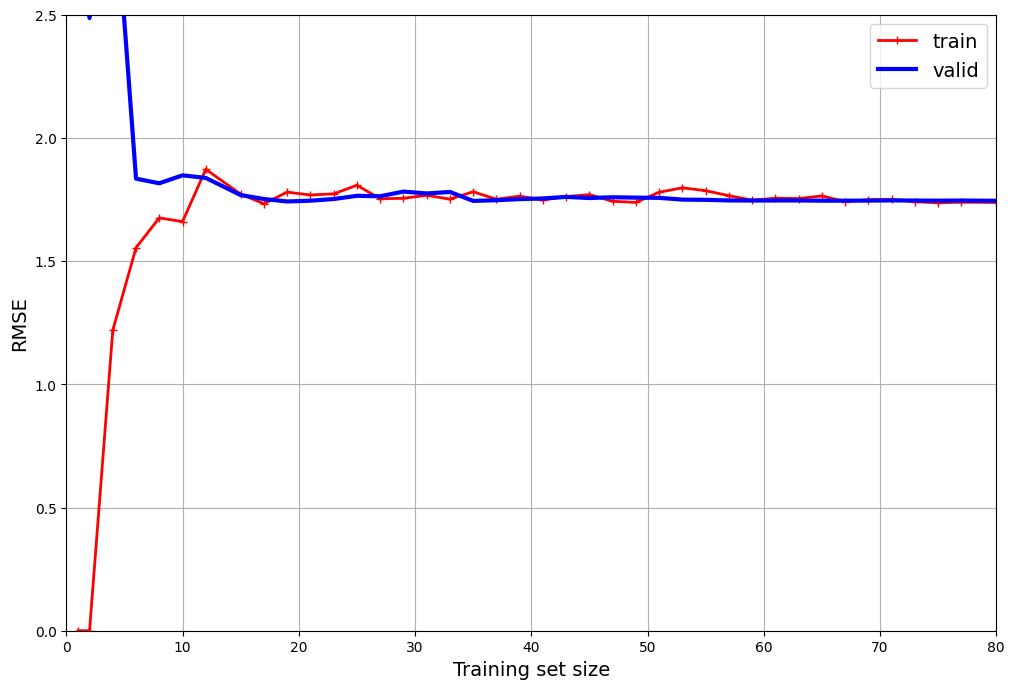

In [36]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X, y, train_sizes = np.linspace(0.01 , 1.0 , 40),
    cv = 5,
    scoring='neg_root_mean_squared_error'
)

train_errors = - train_scores.mean(axis = 1)
valid_errors = - valid_scores.mean(axis = 1)

plt.figure(figsize = (12, 8))
plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label='train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth = 3, label='valid')

plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.grid()
plt.legend(loc='upper right')
plt.axis([0, 80, 0, 2.5])

plt.show()


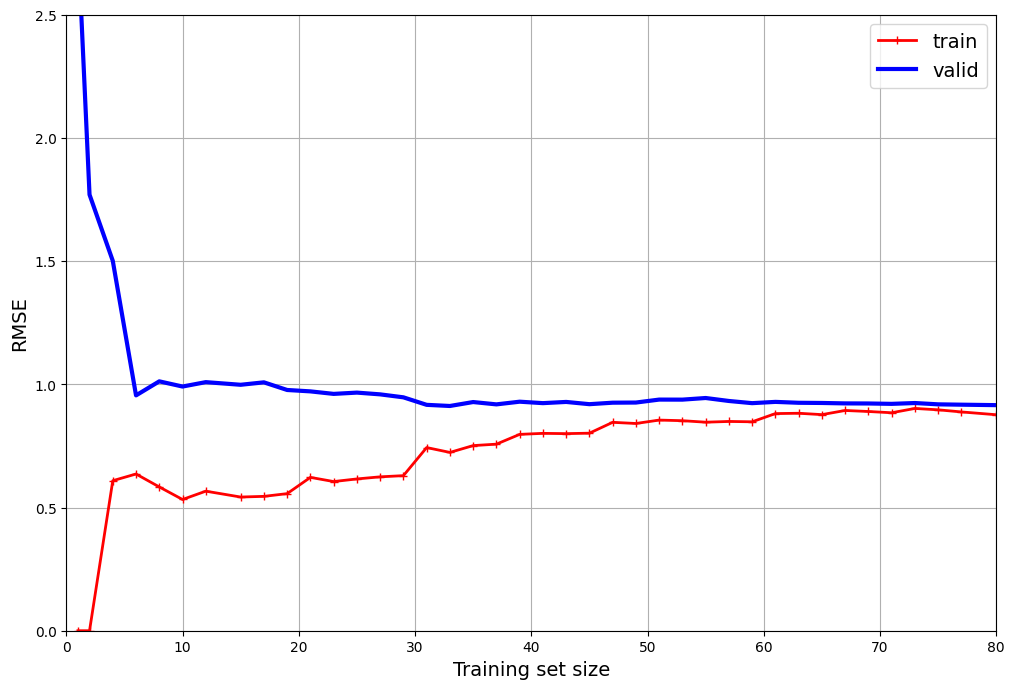

In [37]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=2 , include_bias= False),
    LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring='neg_root_mean_squared_error'
)

train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize = (12, 8))
plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label='train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth = 3, label='valid')

plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.grid()
plt.legend(loc='upper right')
plt.axis([0, 80, 0, 2.5])

plt.show()


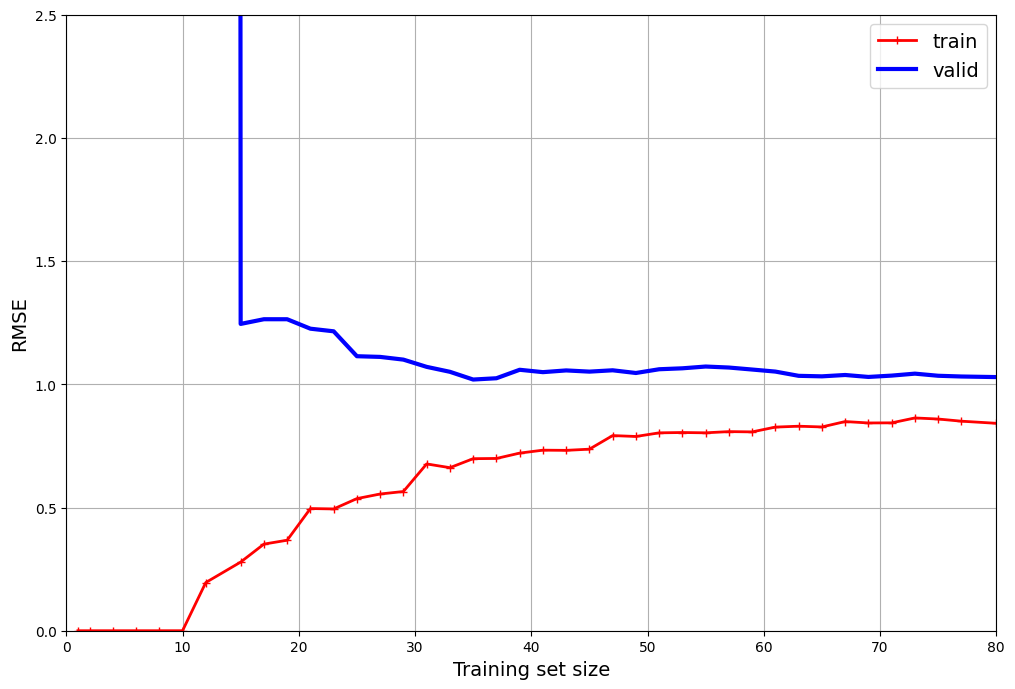

In [38]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10 , include_bias= False),
    LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring='neg_root_mean_squared_error'
)

train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize = (12, 8))
plt.plot(train_sizes, train_errors, 'r-+', linewidth = 2, label='train')
plt.plot(train_sizes, valid_errors, 'b-', linewidth = 3, label='valid')

plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.grid()
plt.legend(loc='upper right')
plt.axis([0, 80, 0, 2.5])

plt.show()


# Regularized Linear Models

# Ridge Regression or L2 regularization
L2 ridge --> butun sutunlarda regularization eidr,

L1 lasso tekce az contribution eden sutunlari 0'a vuraraq onlari kenarlashdirir

Regularization tekce train zamani ishleyir, daha yaxsi oyrenmek uchundur

regularization cost w'nin qiymetini azaldir, gradient descent cost functionu azaldir

In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
np.random.seed(42)
m=20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

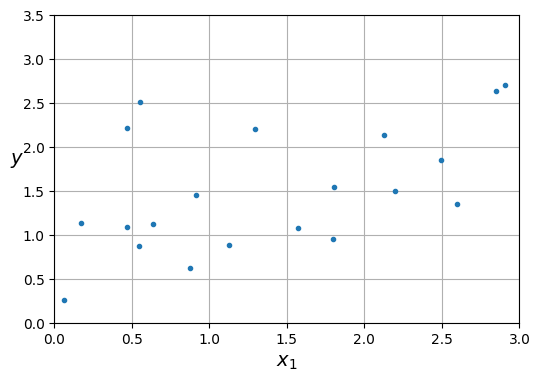

In [41]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, '.')
plt.xlabel('$x_1$')
plt.ylabel('$y$', rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [42]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha = 0.1, solver='cholesky')
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

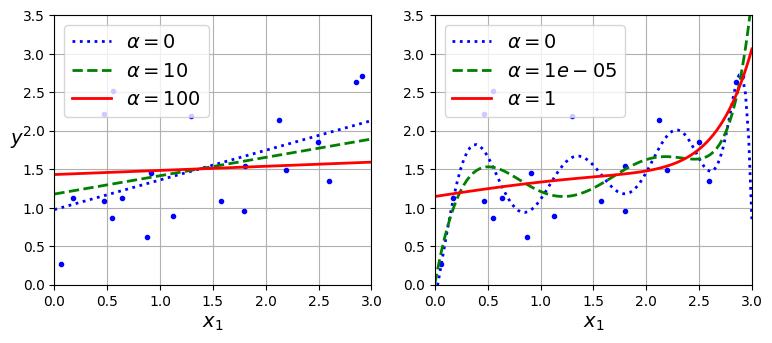

In [43]:
from sklearn.preprocessing import StandardScaler

def plot_model(model_class, polynomial, alphas, **model_kwargs):
  plt.plot(X, y , 'b.', linewidth = 3)
  for alpha, style, in zip(alphas, ('b:', 'g--', 'r-')):
    if alpha > 0 :
      model = model_class(alpha, **model_kwargs)
    else:
      model = LinearRegression()
    if polynomial:
      model = make_pipeline(
          PolynomialFeatures(degree = 10, include_bias= False),
          StandardScaler(),
          model
      )
    model.fit(X, y)
    y_new_regul = model.predict(X_new)
    plt.plot(X_new, y_new_regul, style, linewidth = 2,
             label=fr'$\alpha = {alpha}$')
  plt.legend(loc='upper left')
  plt.xlabel('$x_1$')
  plt.axis([0, 3, 0, 3.5])
  plt.grid()


plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state = 42)
plt.ylabel('$y$', rotation= 0)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.show()

In [44]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty= 'l2',
                       max_iter = 1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.47012588])

In [45]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio = 0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

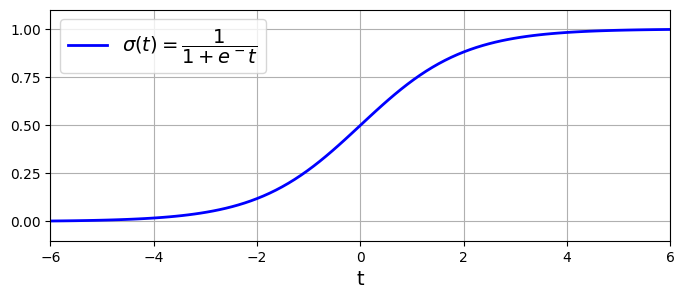

In [47]:
lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1/ (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot(t, sig, 'b-', linewidth=2, label=r'$\sigma(t) = \dfrac{1}{1+e^-t}$')
plt.xlabel('t')
plt.legend(loc='upper left')
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

In [48]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame = True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [49]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [50]:
iris.target.head(3)

,target
0,0
1,0
2,0


In [51]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

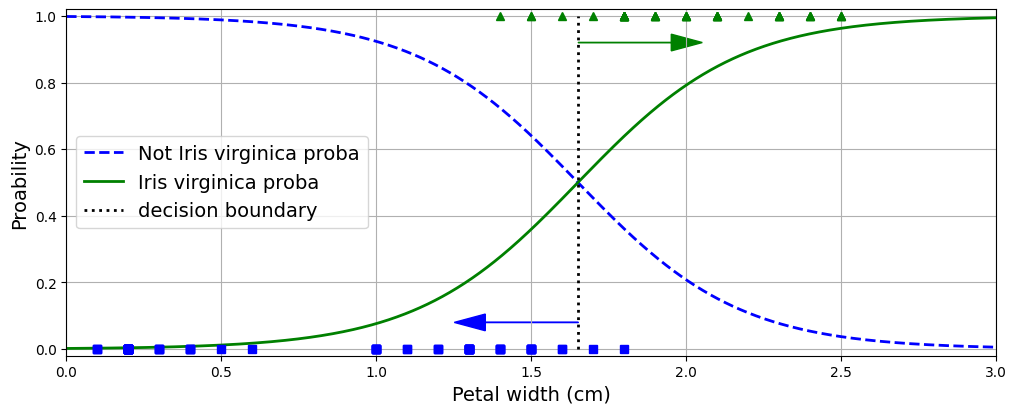

In [53]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(12, 4.5))
plt.plot(X_new, y_proba[:, 0], 'b--', linewidth=2,
         label='Not Iris virginica proba')
plt.plot(X_new, y_proba[:, 1], 'g-', linewidth=2, label='Iris virginica proba')
plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', linewidth=2,
         label='decision boundary')

plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0,
          head_width=0.05, head_length=0.1, fc='b', ec='b')
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0,
          head_width=0.05, head_length=0.1, fc='g', ec='g')

plt.plot(X_train[y_train == 0], y_train[y_train == 0], 'bs')
plt.plot(X_train[y_train == 1], y_train[y_train == 1], 'g^')


plt.xlabel('Petal width (cm)')
plt.ylabel('Proability')
plt.legend(loc = 'center left')
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.show()